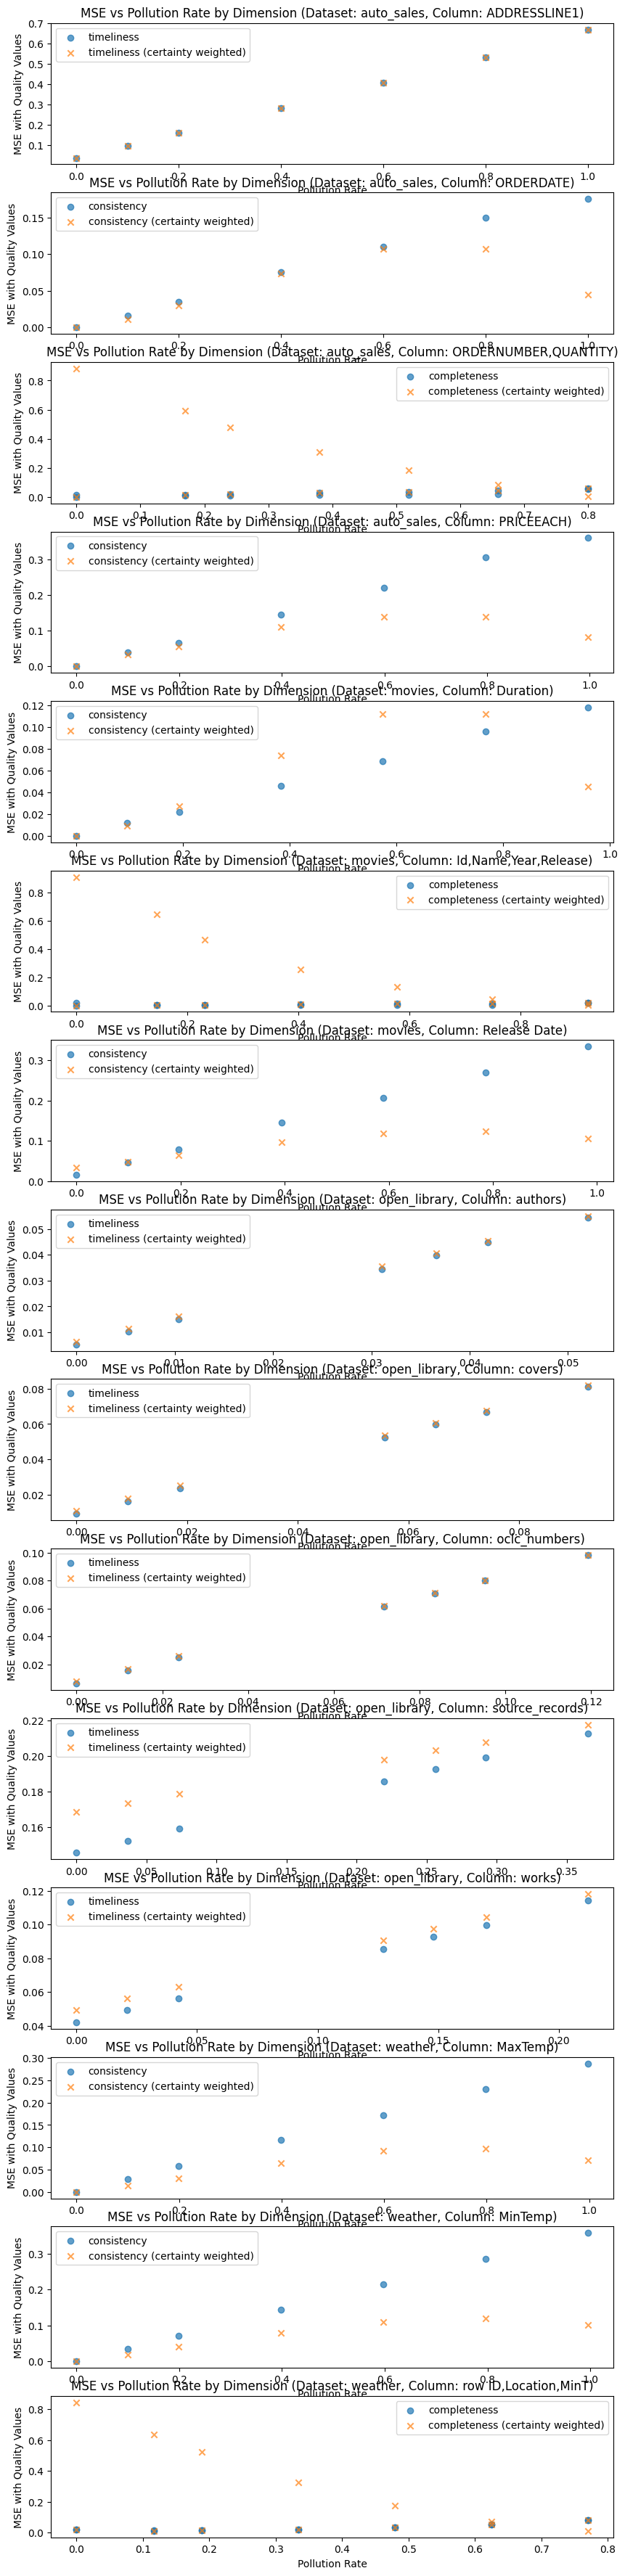

In [19]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd


with open("../data-pollution/.latest_pollutions.json", "r") as f:
    latest = json.load(f)

evaluations = {
    (dim, Path(folder).name): json.load(
        (Path(folder) / dim / "results" / "evaluations.json").open()
    )
    for folder in latest["polluted_folders"]
    for dim in ["timeliness", "completeness", "consistency"]
}

df = pd.DataFrame(
    [
        {
            "dimension": dim,
            "folder": folder,
            "metric": metric,
            "dataset": dataset.split(".")[0],
            "column": column,
            "null_rate": results["dq_results_stats"]["null_rates"][column],
            "dq_results_mean": results["dq_results_stats"]["describe"][column]["mean"],
            "pollution_rate": results["pollution_rates"][column],
            "dq_certainty_mean": results["dq_certainties_stats"]["describe"][column][
                "mean"
            ],
            "mse_dq": results["mse_per_column"]["With quality values"][column],
            "mse_dq_certainty": results["mse_per_column"]["With certainty weighting"][
                column
            ],
        }
        for (dim, folder), evaluation in evaluations.items()
        for metric, datasets in evaluation.items()
        for dataset, results in datasets.items()
        for column in results["dq_results_stats"]["describe"].keys()
    ]
)

df.to_csv(".evaluation_summary.csv", index=False)

groups = df.groupby(["dataset", "column"])

# plot mse vs pollution rate
fig, axes = plt.subplots(len(groups), figsize=(10, 3 * len(groups)))

for (group_key, data), ax in zip(groups, axes):
    ds, col = group_key
    for dim in data["dimension"].unique():
        dim_data = data[data["dimension"] == dim]
        ax.scatter(
            dim_data["pollution_rate"],
            dim_data["mse_dq"],
            label=dim,
            alpha=0.7,
        )
        ax.scatter(
            dim_data["pollution_rate"],
            dim_data["mse_dq_certainty"],
            label=f"{dim} (certainty weighted)",
            alpha=0.7,
            marker="x",
        )
    ax.set_xlabel("Pollution Rate")
    ax.set_ylabel("MSE with Quality Values")
    ax.set_title(
        "MSE vs Pollution Rate by Dimension (Dataset: {}, Column: {})".format(
            ds, col[:20]
        )
    )
    ax.legend()
plt.show()

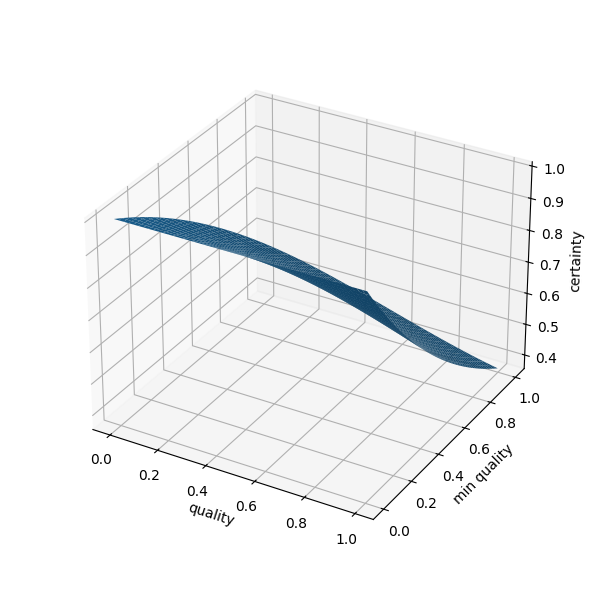

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("_mpl-gallery")


def certainty(q, min_q):
    return np.where(q >= min_q, np.exp(-min_q * q), np.nan)
    # return np.sqrt((1 / np.exp(q)) * (1 - min_q))
    # return np.where(q >= min_q, np.sqrt((1 - q) * (1 - min_q)), 0)


# Make data
Q = np.arange(0, 1, 0.001)
Q_min = np.arange(0, 1, 0.001)
Q, Q_min = np.meshgrid(Q, Q_min)
Z = certainty(Q, Q_min)

# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))
# ax.view_init(elev=20, azim=140, roll=0)
ax.plot_surface(Q, Q_min, Z, vmin=Z.min())
ax.set_xlabel("quality")
ax.set_ylabel("min quality")
ax.set_zlabel("certainty")
ax.set_box_aspect(None, zoom=0.85)
# ax.set(xticklabels=[], yticklabels=[], zticklabels=[])

plt.show()

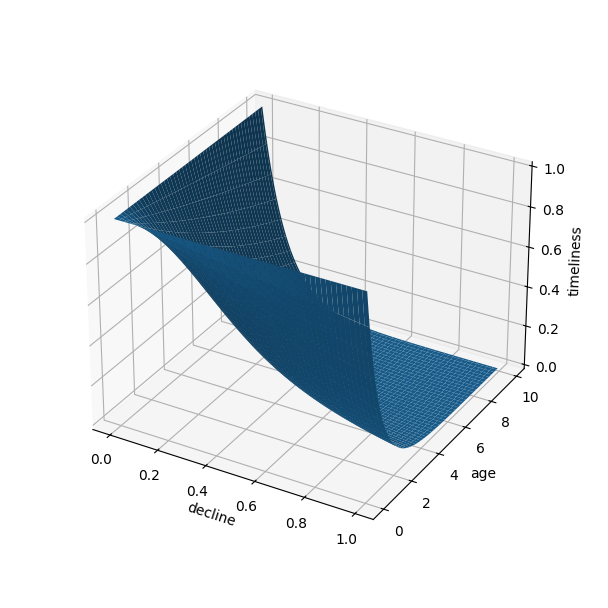

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("_mpl-gallery")


def timeliness(decline, age):
    return np.exp(-decline * age)


# Make data
decline = np.arange(0, 1, 0.001)
x = np.arange(0, 10, 0.1)
decline, x = np.meshgrid(decline, x)
Z = timeliness(decline, x)

# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))
ax.plot_surface(decline, x, Z, vmin=Z.min())
ax.set_xlabel("decline")
ax.set_ylabel("age")
ax.set_zlabel("timeliness")
ax.set_box_aspect(None, zoom=0.85)
# ax.set(xticklabels=[], yticklabels=[], zticklabels=[])

plt.show()

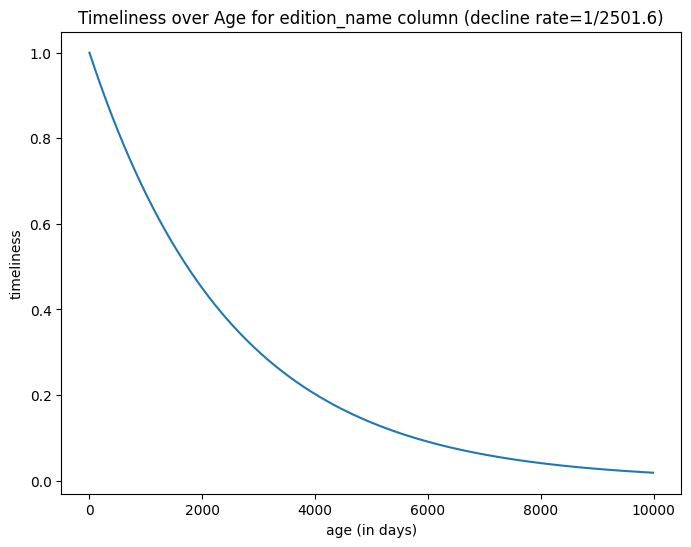

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def timeliness(decline, age):
    return np.exp(-decline * age)


# Make data
decline = 1 / 2501.6
x = np.arange(0, 10000, 10)
Z = timeliness(decline, x)
# Plot the timeliness graph
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, Z)
ax.set_xlabel("age (in days)")
ax.set_ylabel("timeliness")
ax.set_title("Timeliness over Age for edition_name column (decline rate=1/2501.6)")

plt.show()

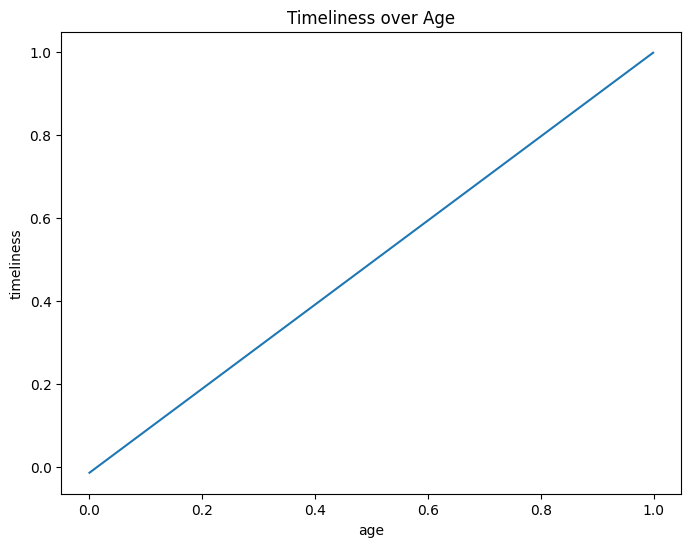

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def f(x):
    return (x - 0.4292**5) / (1 - 0.4292**5)


# Make data
x = np.arange(0, 1, 0.001)
Z = f(x)
# Plot the timeliness graph
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, Z)
ax.set_xlabel("age")
ax.set_ylabel("timeliness")
ax.set_title("Timeliness over Age")

plt.show()

In [4]:
import pandas as pd

df1 = pd.DataFrame([{"a": 1}, {"b": 2}])

df2 = pd.DataFrame([{"c": 3}, {"d": 4}])

df1.to_csv(
    "test.csv",
    mode="w",  # Write first, append rest
    header=True,  # Write header only for first chunk
    index=False,
)

df2.to_csv(
    "test.csv",
    mode="a",  # Write first, append rest
    header=True,  # Write header only for first chunk
    index=False,
)

Subset size: 0.009878213802435724
∆λ: 0.04631405022334961
∆θ: 0.17217229011668728


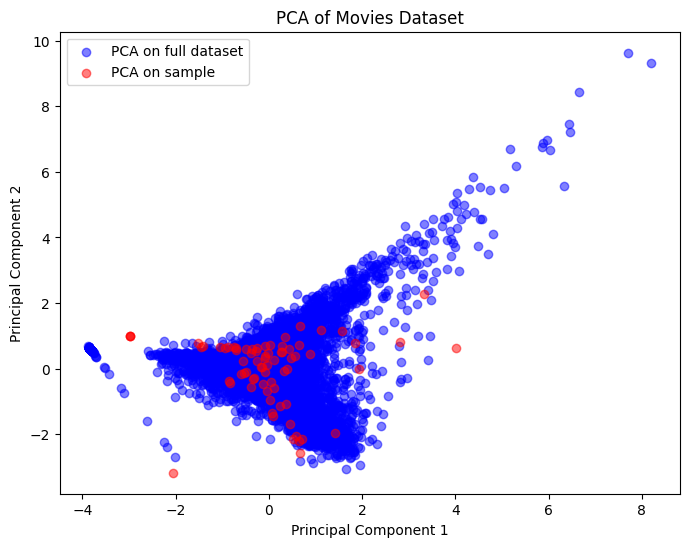

Subset size: 0.1
∆λ: 0.008130820111917458
∆θ: 0.13719394475256502


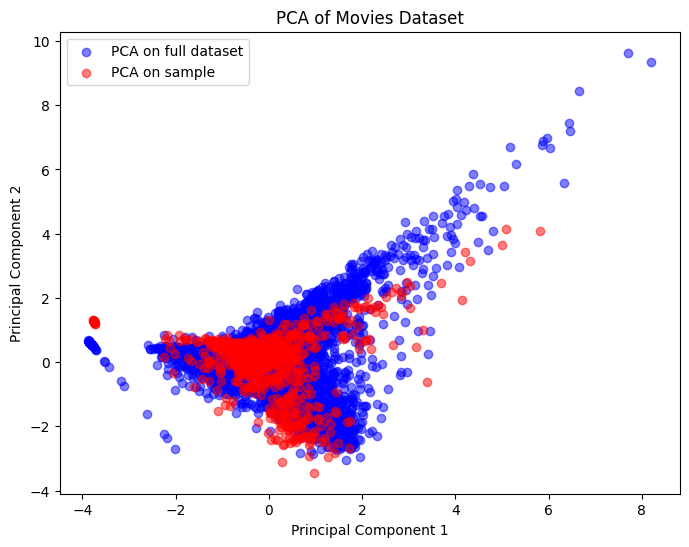

Subset size: 0.5
∆λ: 0.0008642617973823041
∆θ: 0.022737062165955214


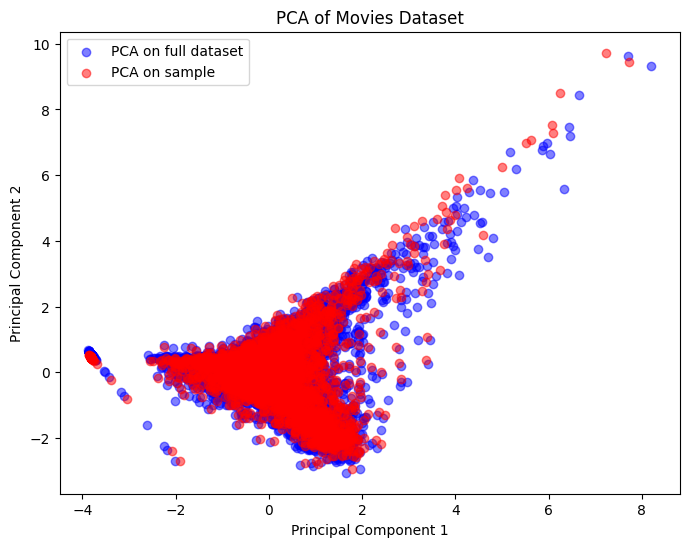

Subset size: 0.2553450608930988
∆λ: 0.2262445779185039
∆θ: 0.16023803594676733


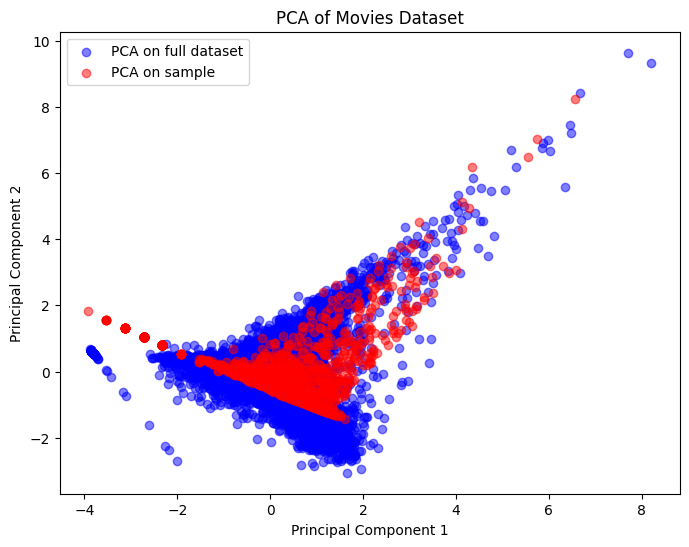

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

data = pd.read_csv(
    "/Users/jberndt/Documents/Masterarbeit/data-pollution/data/clean/movies.csv"
)
encoder = OrdinalEncoder(encoded_missing_value=-1).fit(
    data.select_dtypes(exclude=["object", "number"])
)
vectorizer = TfidfVectorizer()
concatenated_strings = (
    data.select_dtypes(include=["object"]).fillna("").agg(" ".join, axis=1)
)
X = encoder.transform(data.select_dtypes(exclude=["object", "number"]))
X = np.hstack((data.select_dtypes(include=["number"]).fillna(-1).to_numpy(), X))
# vectorizer.fit(concatenated_strings)
# S_X = vectorizer.transform(concatenated_strings)
# X = np.hstack((X, S_X.toarray()))
scaler = StandardScaler()
X = scaler.fit_transform(X)
n_features = X.shape[1]
n_components = 2
X_pca = PCA(n_components=n_components)
X_pca.fit(X)

X_reduced = X_pca.transform(X)

for idx in [
    np.random.choice(data.index, size=data.shape[0] // 100, replace=False),
    np.random.choice(data.index, size=data.shape[0] // 10, replace=False),
    np.random.choice(data.index, size=data.shape[0] // 2, replace=False),
    data[(data["Year"] > 2010)].index,
]:
    print("Subset size:", idx.size / data.shape[0])

    Y = X[idx]
    Y = scaler.fit_transform(Y)

    Y_pca = PCA(n_components=n_components)
    Y_pca.fit(Y)

    print(
        "∆λ:",
        n_features
        / (n_features + n_components - 2)
        * np.sum(
            np.abs(X_pca.explained_variance_ratio_ - Y_pca.explained_variance_ratio_)
        ),
    )
    print(
        "∆θ:",
        2
        / np.pi
        * min(
            np.arccos(
                np.clip(np.dot(X_pca.components_[0], Y_pca.components_[0]), -1.0, 1.0)
            ),
            np.arccos(
                np.clip(np.dot(X_pca.components_[0], -Y_pca.components_[0]), -1.0, 1.0)
            ),
        ),
    )

    Y_reduced = Y_pca.transform(Y)
    fig = plt.figure(figsize=(8, 6))
    plt.scatter(
        X_reduced[:, 0],
        X_reduced[:, 1],
        c="blue",
        label="PCA on full dataset",
        alpha=0.5,
    )
    plt.scatter(
        Y_reduced[:, 0],
        Y_reduced[:, 1],
        c="red",
        label="PCA on sample",
        alpha=0.5,
    )
    plt.legend()
    plt.title("PCA of Movies Dataset")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

In [ ]:
# Timeliness

from datetime import datetime
import pandas as pd
import numpy as np


original_data = pd.DataFrame(
    [
        {
            "edition_name": "First edition",
            "title": "The Scout's Outdoor Cookbook",
            "revision": 11,
            "last_modified": "2024-01-19T05:15:17.185339",
        },
        {
            "edition_name": "First edition",
            "title": "Road Bike Maintenance",
            "revision": 13,
            "last_modified": "2023-01-14T23:00:26.172383",
        },
        {
            "edition_name": "7th edition",
            "title": "Orland Florida Metro Area Street Atlas",
            "revision": 3,
            "last_modified": "2025-12-02T22:55:29.961812",
        },
    ]
)

polluted_data = pd.DataFrame(
    [
        {
            "edition_name": "First edition",
            "title": "Outdoor Cookbook",
            "revision": 10,
            "last_modified": "2023-11-10T15:50:01.245902",
        },
        {
            "edition_name": "First edition",
            "title": "Road Bike Maintenance",
            "revision": 13,
            "last_modified": "2023-01-14T23:00:26.172383",
        },
        {
            "edition_name": "7. edition",
            "title": "Orland Florida Street Atlas",
            "revision": 2,
            "last_modified": "2025-11-27T10:35:36.923053",
        },
    ]
)
assessment_date = datetime.fromisoformat("2026-01-19T12:00:00.000000")
ages = assessment_date - pd.to_datetime(polluted_data["last_modified"])
ages_in_days = ages.dt.total_seconds() / (3600 * 24)
decline_rates = np.array([[2501.6, 4760.34, 1147.03, 1147.03]] * len(polluted_data))
qualities = np.exp(
    -1
    / decline_rates
    * np.repeat(ages_in_days.to_numpy().reshape(-1, 1), len(decline_rates[0]), axis=1)
)

print(
    """
| age       | $q\\_time_{edition\\_name}$ | $q\\_time_{title}$ | $q\\_time_{revision}$ | $q\\_time_{last\\_modified}$ |
| --------- | ------------------------- | ----------------- | -------------------- | -------------------------- |
| $800.84$  | $0.$                  | $0.8452$          | $0.4972$             | $0.4972$                   |
| $1100.54$ | $0.6441$                  | $0.7936$          | $0.3828$             | $0.3828$                   |
| $53.06$   | $0.9790$                  | $0.9889$          | $0.9548$             | $0.9548$                   |
"""
    + f""
)

<>:62: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:62: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
/var/folders/rw/xym_kq6n3l9_0qkvb5l3bd_w0000gn/T/ipykernel_45265/436227875.py:62: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  | age       | $q\_time_{edition\_name}$ | $q\_time_{title}$ | $q\_time_{revision}$ | $q\_time_{last\_modified}$ |


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import json

data = pd.read_csv(
    "/Users/jberndt/Documents/Masterarbeit/data-pollution/data/polluted/20260127_224826/timeliness/polluted_open-library-b0.mask.csv"
)
print(json.dumps(data.mean().sort_values().to_dict(), indent=2))

{
  "subject_places": 0.0,
  "scan_on_demand": 0.0,
  "isbn_odd_length": 0.0,
  "create": 0.0,
  "type_key": 0.0,
  "isbn_invalid": 0.0,
  "key": 0.0,
  "purchase_url": 0.0,
  "subject_people": 0.0,
  "oclc": 0.0,
  "word_count": 0.0,
  "original_isbn": 0.0,
  "lc_classification": 0.0,
  "subject_times": 0.0,
  "volumes": 1.7419023315362708e-06,
  "subject_time": 3.4838046630725417e-06,
  "collections": 3.4838046630725417e-06,
  "url": 5.225706994608812e-06,
  "links": 5.225706994608812e-06,
  "providers": 6.967609326145083e-06,
  "oclc_number": 8.709511657681355e-06,
  "openlibrary": 1.3935218652290167e-05,
  "work_titles": 1.3935218652290167e-05,
  "location": 1.5677120983826438e-05,
  "subject_place": 1.741902331536271e-05,
  "coverimage": 1.9160925646898977e-05,
  "genres": 2.090282797843525e-05,
  "work_title": 2.264473030997152e-05,
  "author": 3.1354241967652876e-05,
  "scan_records": 3.483804663072542e-05,
  "full_title": 8.535321424527726e-05,
  "dewey_decimal_class": 0.000113